In [1]:
import polars as pl
import numpy as np
from matplotlib import pyplot as plt

In [2]:
def bump(x, a, b):
    z = (x - b) * a
    return np.where(np.abs(z) >= 1, 0, np.exp(-1 / (1 - z**2)))

In [3]:
def generate_bump_ds(a, l, train, val, test, seed=42):
    N = train + val + test
    xs = np.linspace(0, 1, l)[None].repeat(N, 0)
    rng = np.random.default_rng(seed)
    r = 1 / a
    b = rng.random(N) * (1 - 2 * r) + r
    target = rng.random(N) > 0.5
    ys = bump(xs, a, b[:, None]) * target[:, None]
    return (
        pl.DataFrame({"time": xs.tolist(), "y": ys.tolist(), "target": target.tolist()})
        .with_row_index()
        .with_columns(
            split=pl.when(pl.col("index") < train)
            .then(pl.lit("train"))
            .when(pl.col("index") < train + val)
            .then(pl.lit("val"))
            .otherwise(pl.lit("test"))
        )
        .drop("index")
    )

In [ ]:
generate_bump_ds(20, 600, 1024, 256, 256).write_parquet(
    "/mnt/data/preprocessed/bump20.parquet"
)


/tmp/ipykernel_210662/4210643979.py:3: RuntimeWarning: overflow encountered in exp
  return np.where(np.abs(z) >= 1, 0, np.exp(-1 / (1 - z**2)))


/tmp/ipykernel_210662/4210643979.py:3: RuntimeWarning: overflow encountered in exp
  return np.where(np.abs(z) >= 1, 0, np.exp(-1 / (1 - z**2)))


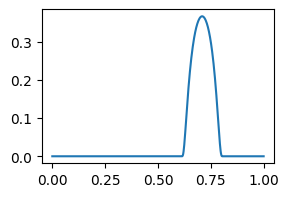

In [5]:
df = generate_bump_ds(10, 600, 1024, 32, 32)
xs, ys = df.filter(target=True).row(1)[:2]

plt.figure(figsize=(3, 2))
plt.plot(xs, ys)
plt.savefig("/app/assets/bump-sample.pdf")